In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [92]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [93]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1.0,6.0,2012.0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2.0,6.0,2012.0,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3.0,6.0,2012.0,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4.0,6.0,2012.0,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5.0,6.0,2012.0,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [94]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='str')

In [95]:
## drop month, day and year
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [96]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [97]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Classes       1
Name: count, dtype: int64

### Encoding

In [98]:
df['Classes'] = np.where(df['Classes'].str.contains("not fire"),0,1)

In [99]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
241,30.0,65.0,14.0,0,85.4,16,44.5,4.5,16.9,6.5,1
242,28.0,87.0,15.0,4.4,41.1,6.5,8,0.1,6.2,0,0
243,27.0,87.0,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0
244,24.0,54.0,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0
245,24.0,64.0,15.0,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0


In [100]:
df['Classes'].value_counts()

Classes
1    140
0    106
Name: count, dtype: int64

In [101]:
## Independent And dependent features
X=df.drop('FWI',axis=1) # Independent feature
y=df['FWI'] # Dependent feature

In [102]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0
4,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0


## Train Test Split

In [103]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [104]:
X_train.shape, X_test.shape

((184, 10), (62, 10))

## Feature Selection Based on Correlation

In [105]:
X_train.corr(numeric_only=True)

,Temperature,RH,Ws,Classes
Temperature,1.000000,-0.677790,-0.298948,0.528069
RH,-0.677790,1.000000,0.196626,-0.459550
Ws,-0.298948,0.196626,1.000000,-0.068275
Classes,0.528069,-0.459550,-0.068275,1.000000


## Check for Multicollinearity

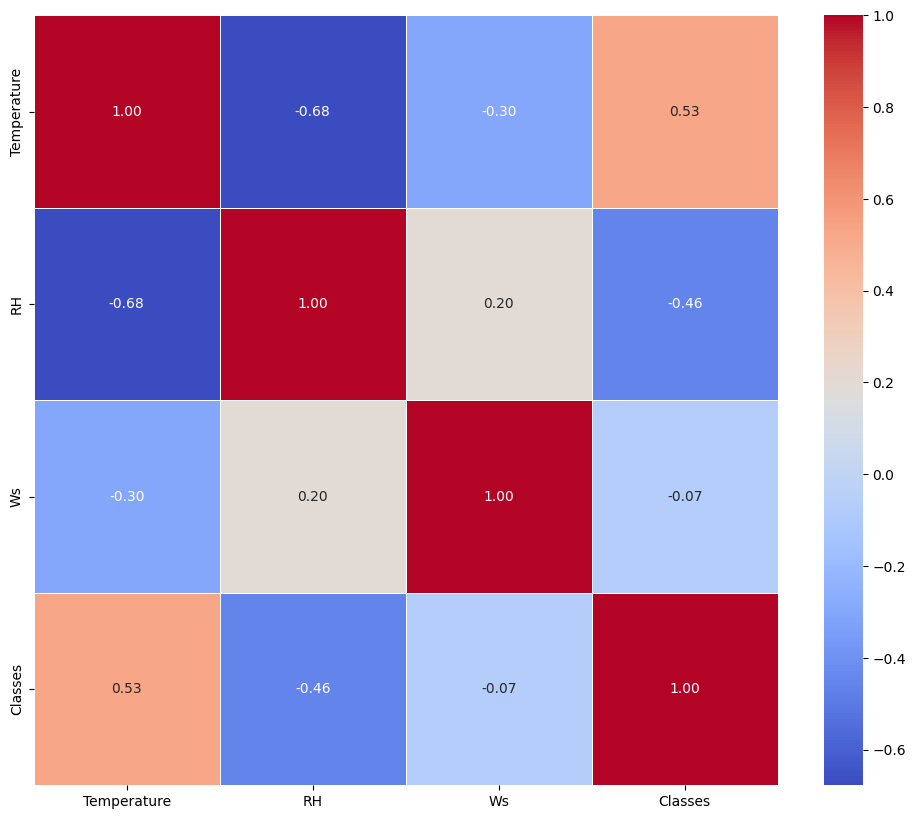

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

corr = X_train.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.show()

In [107]:
X_train = X_train.select_dtypes(include='number')

In [108]:
corr_features = correlation(X_train, 0.85)
print(corr_features)

set()


In [109]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')

In [110]:
print(X_train.dtypes)

Temperature    float64
RH             float64
Ws             float64
Classes          int64
dtype: object


In [111]:
X_train['Classes'] = X_train['Classes'].map({'not fire':0, 'fire':1})

In [112]:
def correlation(dataset, threshold):
    col_corr = set()  # set of correlated columns
    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

In [113]:
corr_features

set()

In [114]:
corr_features = correlation(X_train, 0.85)
print(corr_features)

set()


In [115]:
## drop features when correlation is more than 0.85 
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((184, 4), (62, 10))

## Feature Scaling or Standardization

In [134]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # ← this was missing earlier

# Convert to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [117]:
X_train = X_train.select_dtypes(include='number')
X_test = X_test.select_dtypes(include='number')

In [118]:
print(X_train.columns.equals(X_test.columns))  # should be True

True


In [119]:
print(X_train.isnull().sum())

Temperature      2
RH               2
Ws               2
Classes        184
dtype: int64


In [120]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [121]:
import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [122]:
X_train_scaled

,Temperature,RH,Ws,Classes
0,0.219680,0.710133,-1.343217,NaN
1,0.763649,-1.861564,0.187083,NaN
2,-0.868259,1.171720,-0.578067,NaN
3,0.763649,-0.213040,0.569658,NaN
4,2.123572,-1.399977,-2.108367,NaN
...,...,...,...,...
179,-2.228182,1.303602,-0.195492,NaN
180,-1.140243,1.171720,0.569658,NaN
181,-1.956197,0.907956,0.569658,NaN
182,0.763649,-0.278981,-2.108367,NaN


In [123]:
X_test_scaled

,Temperature,RH,Ws,Classes


## Box plots to understand effect of StandardScaler

Text(0.5, 1.0, 'X_train After Scaling')

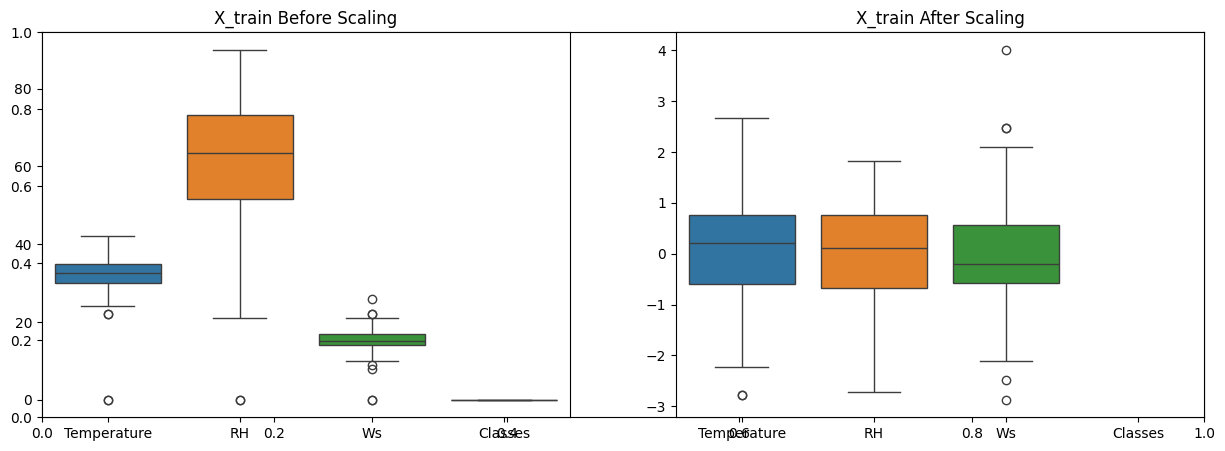

In [124]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

## Linear Regression Model

In [125]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [126]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [127]:
import numpy as np

print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_test:", np.isnan(X_test).sum())

NaNs in X_train: 0
NaNs in X_test: 0


In [128]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [129]:
print(np.isnan(X_train).sum())  # should be 0
print(np.isnan(X_test).sum())   # should be 0

0
0


In [130]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
import numpy as np

print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaNs in X_test_scaled:", np.isnan(X_test_scaled).sum())
print("NaNs in y_train:", pd.isnull(y_train).sum())
print("NaNs in y_test:", pd.isnull(y_test).sum())

NaNs in X_train_scaled: 0
NaNs in X_test_scaled: 0
NaNs in y_train: 1
NaNs in y_test: 0


In [131]:
# Create mask for non-NaN values in y_train
mask = ~pd.isnull(y_train)

# Apply same mask to both X and y
X_train_scaled = X_train_scaled[mask]
y_train = y_train[mask]

In [136]:
print(pd.isnull(y_train).sum())  # should be 0

0


In [137]:
# Combine X and y to keep alignment
train_df = pd.concat([pd.DataFrame(X_train_scaled), y_train], axis=1)

# Drop NaN
train_df = train_df.dropna()

# Split again
X_train_scaled = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

In [138]:
print(y_train.unique())

<StringArray>
[ '0.5',  '0.4',  '0.1',    '0',  '2.5',  '7.1',  '0.3',  '0.2',  '2.2',
  '2.3',  '3.8',  '7.5',   '15', '13.9',  '3.9', '12.9',  '4.9',  '6.8',
  '3.2',    '8',  '0.9',  '3.4',  '0.8',  '3.6',    '6', '10.9',    '4',
  '8.8',  '2.8',  '2.1',  '1.3',  '7.3', '15.3', '11.3', '11.9', '10.7',
  '6.1',  '9.9', '11.6', '12.1',  '4.2', '10.2', '10.6', '14.6', '16.1',
 '16.8', '18.4', '22.3', '20.9', '20.3', '13.2', '19.9', '30.2',  '0.6',
  '5.9',  '9.7',  '6.3',  '0.7',  'FWI',    '1',  '3.1',   '10', '16.7',
  '1.2',  '6.7',  '9.5',   '12',  '7.2',  '5.2',    '3',  '4.7', 'fire',
 '14.1',  '9.1',   '13',   '30', '25.4', '16.3']
Length: 78, dtype: str


In [139]:
mask = y_train != 'FWI'

X_train_scaled = X_train_scaled[mask]
y_train = y_train[mask]

In [140]:
y_train = y_train.astype(str).str.strip().str.lower()
y_test = y_test.astype(str).str.strip().str.lower()

In [141]:
y_train = y_train.map({'not fire': 0, 'fire': 1})
y_test = y_test.map({'not fire': 0, 'fire': 1})

In [142]:
mask = y_train.notnull()

X_train_scaled = X_train_scaled[mask]
y_train = y_train[mask]

In [143]:
y_test = y_test.astype(str).str.strip().str.lower()
y_test = y_test.map({'not fire': 0, 'fire': 1})

In [144]:
mask = y_test.notnull()

X_test_scaled = X_test_scaled[mask]
y_test = y_test[mask]

In [145]:
y_test = y_test.astype(str).str.strip().str.lower()
y_test = y_test.map({'not fire': 0, 'fire': 1})

In [146]:
import numpy as np

mask = ~pd.isnull(y_test)

X_test_scaled = X_test_scaled[mask]
y_test = y_test[mask]

In [147]:
mask = y_test.notnull()
X_test_scaled = X_test_scaled[mask]

In [148]:
print(X_test_scaled.shape)
print(y_test.shape)

(0, 4)
(0,)


In [149]:
# Convert y_test first
y_test = y_test.astype(str).str.strip().str.lower()
y_test = y_test.map({'not fire': 0, 'fire': 1})

# Only drop rows where y_test is NaN
mask = y_test.notnull()

X_test_scaled = X_test_scaled[mask]
y_test = y_test[mask]

In [150]:
print(y_test.unique())

[]


In [151]:
y_test = y_test.astype(str).str.strip().str.lower()

y_test = y_test.replace({
    'not fire': 0,
    'fire': 1
})

In [152]:
# Clean entire dataset first
df['Classes'] = df['Classes'].astype(str).str.strip().str.lower()
df['Classes'] = df['Classes'].map({'not fire': 0, 'fire': 1})

df = df.dropna()

# Then split again

In [154]:
mask = ~pd.isnull(y_test)
X_test_scaled = X_test_scaled[mask]

In [155]:
print(X_test_scaled.shape)
print(y_test.shape)

(0, 4)
(0,)


In [157]:
print(df.shape)

(0, 11)


In [158]:
df = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv", skiprows=1)

In [159]:
df.columns = df.columns.str.strip()

# Clean target safely
df['Classes'] = df['Classes'].astype(str).str.strip().str.lower()
df['Classes'] = df['Classes'].map({'not fire': 0, 'fire': 1})

# Convert numeric columns
df = df.apply(pd.to_numeric, errors='coerce')

In [160]:
df = df.dropna()   # ❌ removes everything in your case

In [161]:
print(df.shape)

(243, 14)


In [162]:
from sklearn.model_selection import train_test_split

X = df.drop('Classes', axis=1)
y = df['Classes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [163]:
# Go back to original split (before masking)

from sklearn.model_selection import train_test_split

X = df.drop('Classes', axis=1)
y = df['Classes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [164]:
from sklearn.model_selection import train_test_split

X = df.drop('Classes', axis=1)
y = df['Classes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [165]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [166]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [167]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [168]:
y_pred = linreg.predict(X_test_scaled)

In [169]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred = linreg.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.2412025989957715
R2 Score: 0.6609899561487814


In [ ]:
linreg.fit(X_train_scaled, y_train)

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Clean target
df['Classes'] = df['Classes'].astype(str).str.strip().str.lower()
df['Classes'] = df['Classes'].map({'not fire': 0, 'fire': 1})

# Convert all columns to numeric where possible
df = df.apply(pd.to_numeric, errors='coerce')

# Remove all NaNs
df = df.dropna().reset_index(drop=True)

In [170]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [171]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [172]:
y_pred = linreg.predict(X_test_scaled)

In [173]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.2412025989957715
R2 Score: 0.6609899561487814


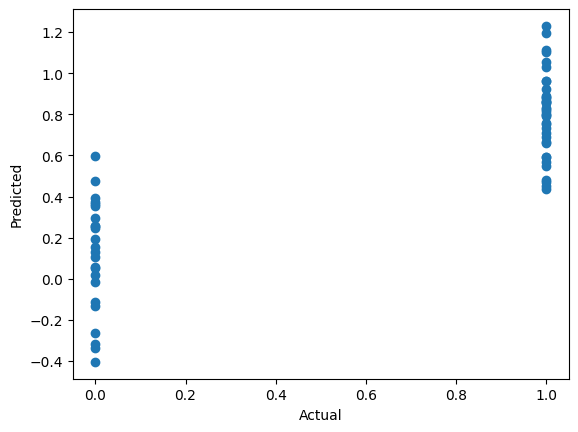

In [174]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## Lasso Regression

Mean absolute error 0.48946135831381726
R2 Score -0.01366541339068772


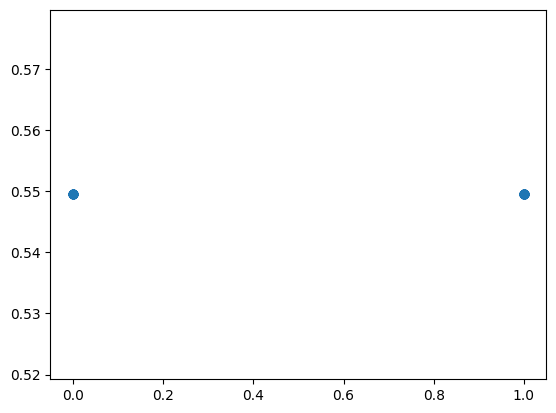

In [175]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## Cross Validation

In [176]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [177]:
lassocv.alpha_

np.float64(0.008374594497289426)

In [178]:
lassocv.alphas_

array([0.38871424, 0.3625162 , 0.33808383, 0.31529811, 0.29404807,
       0.27423021, 0.25574802, 0.23851146, 0.22243658, 0.2074451 ,
       0.19346399, 0.18042517, 0.16826512, 0.15692461, 0.14634842,
       0.13648502, 0.12728639, 0.11870771, 0.11070721, 0.10324592,
       0.09628749, 0.08979803, 0.08374594, 0.07810175, 0.07283795,
       0.06792892, 0.06335074, 0.05908111, 0.05509924, 0.05138574,
       0.04792251, 0.04469269, 0.04168055, 0.03887142, 0.03625162,
       0.03380838, 0.03152981, 0.02940481, 0.02742302, 0.0255748 ,
       0.02385115, 0.02224366, 0.02074451, 0.0193464 , 0.01804252,
       0.01682651, 0.01569246, 0.01463484, 0.0136485 , 0.01272864,
       0.01187077, 0.01107072, 0.01032459, 0.00962875, 0.0089798 ,
       0.00837459, 0.00781017, 0.0072838 , 0.00679289, 0.00633507,
       0.00590811, 0.00550992, 0.00513857, 0.00479225, 0.00446927,
       0.00416806, 0.00388714, 0.00362516, 0.00338084, 0.00315298,
       0.00294048, 0.0027423 , 0.00255748, 0.00238511, 0.00222

In [179]:
lassocv.mse_path_

array([[0.26111515, 0.23694329, 0.24483956, 0.24314026, 0.25379996],
       [0.23946995, 0.22174743, 0.23264696, 0.22357933, 0.23739152],
       [0.22330215, 0.20831302, 0.21098543, 0.20604189, 0.21824386],
       [0.20927863, 0.19642532, 0.19207501, 0.18964069, 0.20149697],
       [0.19711751, 0.18539914, 0.1757244 , 0.17531624, 0.18684279],
       [0.18427006, 0.17388687, 0.16159271, 0.16293637, 0.17401622],
       [0.17293007, 0.16375912, 0.14938391, 0.15224395, 0.16278287],
       [0.1630086 , 0.15419186, 0.13884395, 0.14301339, 0.15294253],
       [0.15432478, 0.14559518, 0.12974921, 0.13463784, 0.14431747],
       [0.14672068, 0.13808559, 0.1219053 , 0.12685637, 0.13645737],
       [0.14005997, 0.13152339, 0.11514731, 0.12020436, 0.12916831],
       [0.13422251, 0.12578764, 0.10932826, 0.11452592, 0.12275831],
       [0.12910406, 0.12077244, 0.10432191, 0.10968839, 0.11711759],
       [0.12461377, 0.11638551, 0.10001871, 0.10557482, 0.1121494 ],
       [0.12067225, 0.11254706, 0.

Mean absolute error 0.25355157558674246
R2 Score 0.6425865136915161


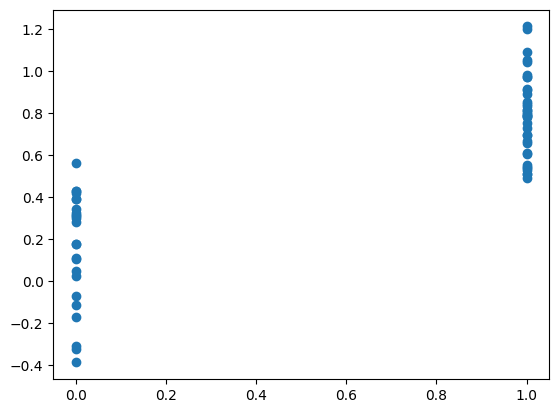

In [180]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

## Ridge Regression Model

Mean absolute error 0.245233831456891
R2 Score 0.6557737499732157


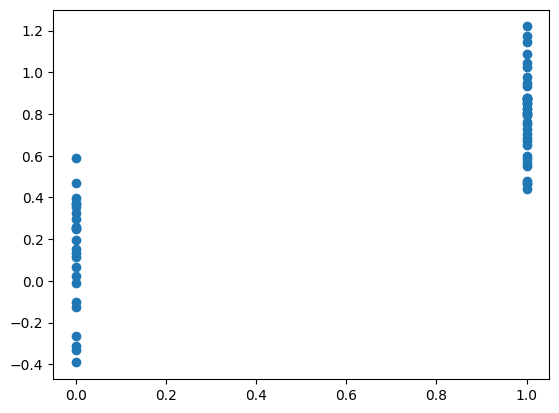

In [181]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## RidgeCV

Mean absolute error 0.245233831456891
R2 Score 0.6557737499732157


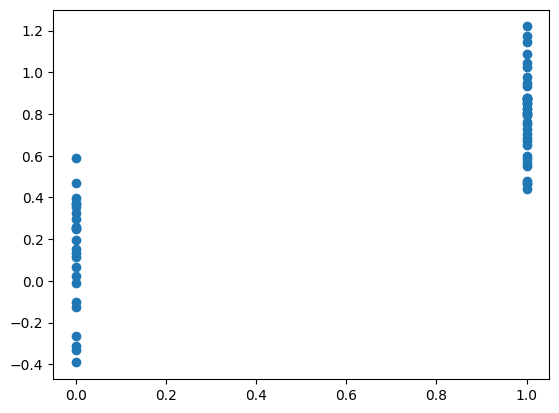

In [182]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [183]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

## ElasticNet Regression

Mean absolute error 0.48946135831381726
R2 Score -0.01366541339068772


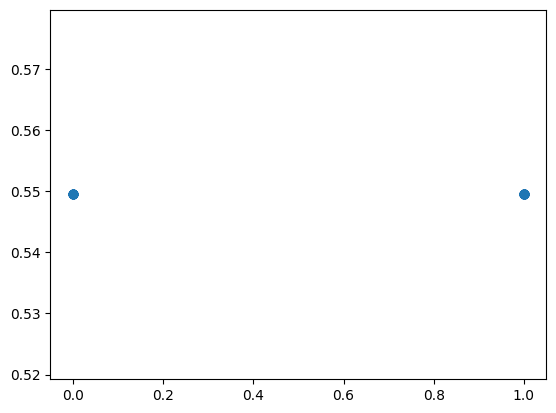

In [184]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## ElasticNet CV

Mean absolute error 0.2537062694891177
R2 Score 0.6422272487247619


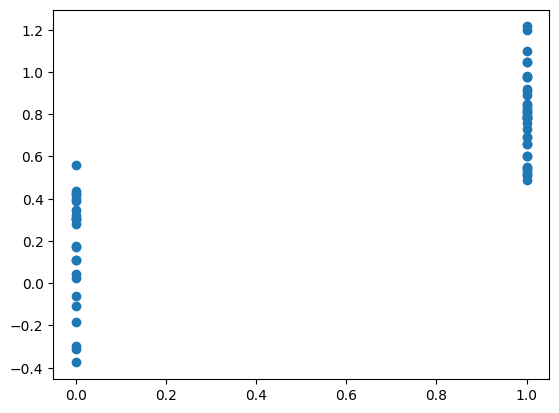

In [185]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [186]:
elasticcv.alphas

'warn'

## Pickle the ML models. preprocessing model standardscaler

In [187]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [188]:
ridge

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [191]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(ridge, open('ridge.pkl', 'wb'))